In [2]:
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.d_CSL import GcStar
from src.dataload import *
from src.dataPreProcessing import replace_nan

# if variables are changed on the fly 
from reloading import reloading
from tqdm.notebook import tqdm

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


In [3]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

In [4]:
# load data 
data = pd.read_csv(r'./data/NTS-NOTEARS/notears_dat.csv', header=None)
X_ = data.values
X = X_.T
print(X.shape)

A_ = pd.read_csv(r'./data/NTS-NOTEARS/W_true.csv', header=None)
A = A_.values

(5, 5000)


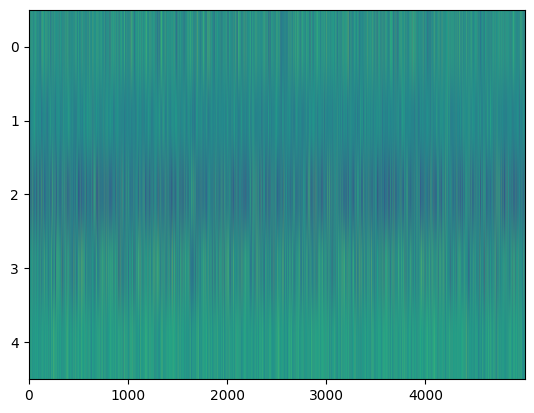

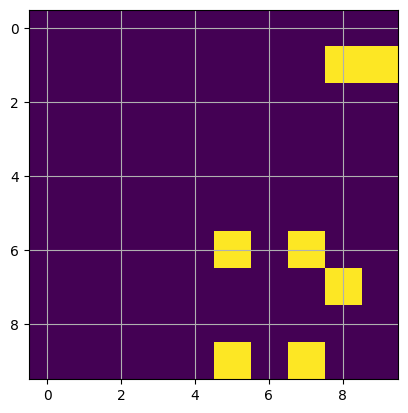

In [5]:
plt.figure()
plt.imshow(X, aspect='auto')

plt.figure()
plt.imshow(A!=0)
plt.grid()

12

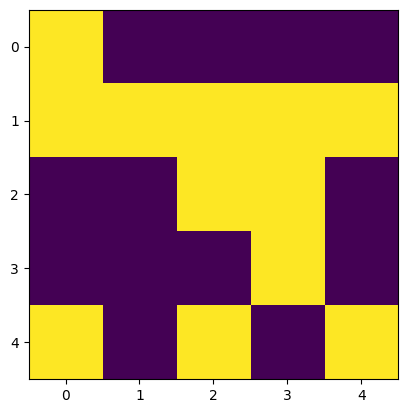

In [6]:
B = np.array([[1,0,0,0,0],
              [1,1,1,1,1],
              [0,0,1,1,0],
              [0,0,0,1,0],
              [1,0,1,0,1]])
# np.fill_diagonal(B, 0)
plt.imshow(B)
aa = np.transpose(np.where(B!=0))
B_ = np.c_[aa,np.ones(len(aa))]
len(B_)
# np.savetxt('notears_gt.csv', B_, delimiter=',')

## Analysis

In [7]:
N_PASTS, n_lags, n_perm = np.arange(3, 6, 1), 2, 1000
alpha, beta = 0, 0

In [8]:
infs_fgc = []
conf_mtx_fgc = []
shds_fgc = []
metrics_fgc = []
for i, n in enumerate(N_PASTS):
    print(f'{n} pasts')
    gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = 'fcgc')
    
    gcstar.fit(X, verbose = 0)
    inf = gcstar.get_connectivity_matrix(alpha=alpha, beta=beta, simulation=False)   # 
    infs_fgc.append(inf)
    conf_mtx_fgc.append(gcstar.compute_confusion_matrix(B))
    metrics_fgc.append(gcstar.all_metrics())
    shds_fgc.append(gcstar.compute_shd_sid(B, inf))
print('')
print('')

3 pasts
4 pasts
5 pasts




In [9]:
print(shds_fgc)
metrics_fgc

[np.float64(7.173027791623717), np.float64(7.173570806156824), np.float64(7.173332133829939)]


[array([0.68      , 0.61111111, 0.91666667, 0.53846154, 0.68910256,
        0.73333333]),
 array([0.68      , 0.61111111, 0.91666667, 0.53846154, 0.68910256,
        0.73333333]),
 array([0.68      , 0.61111111, 0.91666667, 0.53846154, 0.68910256,
        0.73333333])]

In [10]:
infs_gc = []
conf_mtx_gc = []
shds_gc = []
metrics_gc = []
for i, n in enumerate(N_PASTS):
    print(f'{n} pasts')
    gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = 'cgc')
    
    gcstar.fit(X, verbose = 0)
    inf = gcstar.get_connectivity_matrix(alpha=alpha, beta=beta, simulation=False)   # 
    infs_gc.append(inf)
    conf_mtx_gc.append(gcstar.compute_confusion_matrix(B))
    metrics_gc.append(gcstar.all_metrics())
    shds_gc.append(gcstar.compute_shd_sid(B, inf))
print('')
print('')

3 pasts
4 pasts
5 pasts




In [11]:
print(shds_gc)
metrics_gc


[np.float64(7.173027791623717), np.float64(7.173570806156824), np.float64(7.173332133829939)]


[array([0.68      , 0.61111111, 0.91666667, 0.53846154, 0.68910256,
        0.73333333]),
 array([0.68      , 0.61111111, 0.91666667, 0.53846154, 0.68910256,
        0.73333333]),
 array([0.68      , 0.61111111, 0.91666667, 0.53846154, 0.68910256,
        0.73333333])]